In [ ]:
from utils import get_match_df, analyze_strategies, get_best_leagues, get_best_strategies, compare_strategies

df = get_match_df()

df.tail()

/home/maicolnicolini/code/bet-master-analytics/src/strategies/utils.py:132: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  df_final = df_final[other_strategies_mask | dnb_mask]


,date,time,league,home_team,away_team,goal_home,goal_away,strategy,result,return,week
match_id,,,,,,,,,,,
d19637323,2026-03-22,20:00,Argentina B,Acassuso,Deportivo Morón,0,3,DNB 2,True,0.40,11
d19439538,2026-03-22,21:00,La Liga,Sevilla,Valencia,0,2,Over 1.5 (M2-X),True,0.50,11
d19439538,2026-03-22,21:00,La Liga,Sevilla,Valencia,0,2,CN Home (Asiatic),False,-1.00,11
d19452038,2026-03-22,18:00,Grecia,Levadiakos,Atromitos,1,0,DNB 1,True,0.40,11
d19637308,2026-03-22,20:00,Argentina B,Patronato,Colegiales,2,0,Goal HT,True,0.50,11


## Approccio 1: Scommetto tutti i mercati e tutti i campionati

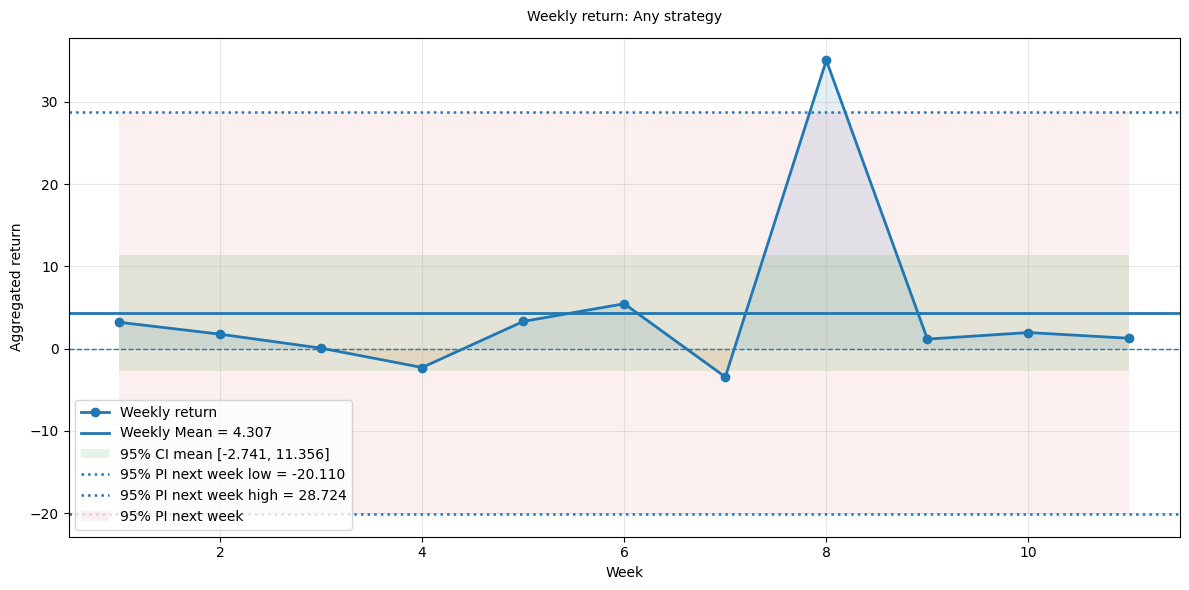

In [128]:
weekly_return, stats = analyze_strategies(df, print_pi=True)

95% PI è la probabilità che il ritorno della prossima settimana sia compreso fra PI low e PI high
### Note:
1. Ritorno medio è positivo ma a estremo inferiore CI negativo -> non è detto che il vero valor medio del ritorno settimanale è > 0
2. 95% PI estremamente variabile

## Approccio 2: scommetto i mercati che si comportano meglio su tutti i campionati

In [129]:
strategy_df = get_best_strategies(df)
strategy_df

,weekly_mean_return,weekly_std_return,weekly_counts,total_counts,accuracy
BTTS,2.99,9.72,5.64,62,0.72
Over 1.5 (M2-X),0.81,2.09,8.00,88,0.77
Goal HT,0.41,1.81,5.73,63,0.81
CN Home (Asiatic),0.37,1.08,3.36,37,0.61
Multigoal 1-2 Home,0.33,1.55,1.09,12,0.75
Win x2 HT,0.24,1.70,2.09,23,0.60
DNB 1,0.21,2.31,7.91,87,0.70
Over 0.5 HT (Live),0.17,1.39,5.55,61,0.78
Win 1,0.05,0.90,2.00,22,0.72
Win 2,0.05,1.07,1.73,19,0.67


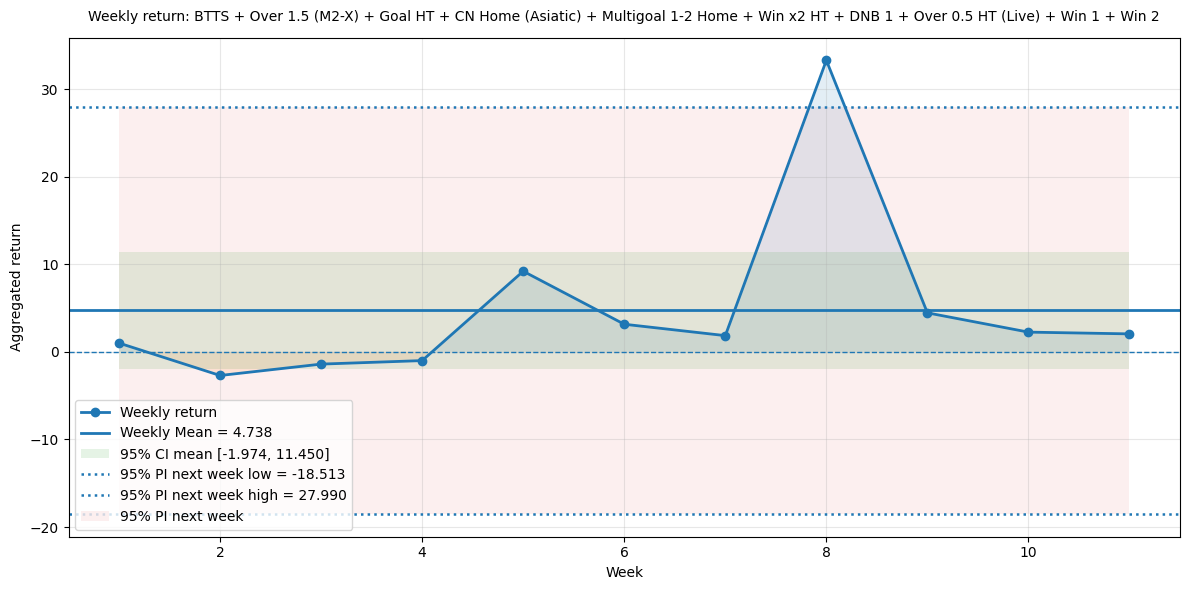

In [130]:
# Tolgo mercati con ritorno medio settimanale negativo e analizzo le strategie
best_strategies = strategy_df[strategy_df["weekly_mean_return"] > 0].index.to_list()
weekly_return, stats = analyze_strategies(df, strategies=best_strategies, print_pi=True)

### Note:
- Valor medio leggermente più alto ma meno confidente (CI mean)
- Intervallo PI maggiore -> più volatile
- Andando a vedere sopra, BTTS è quello che porta più ritorno ma è quello più volatile (ha performato particolarmente bene in week 7), provo a toglierlo

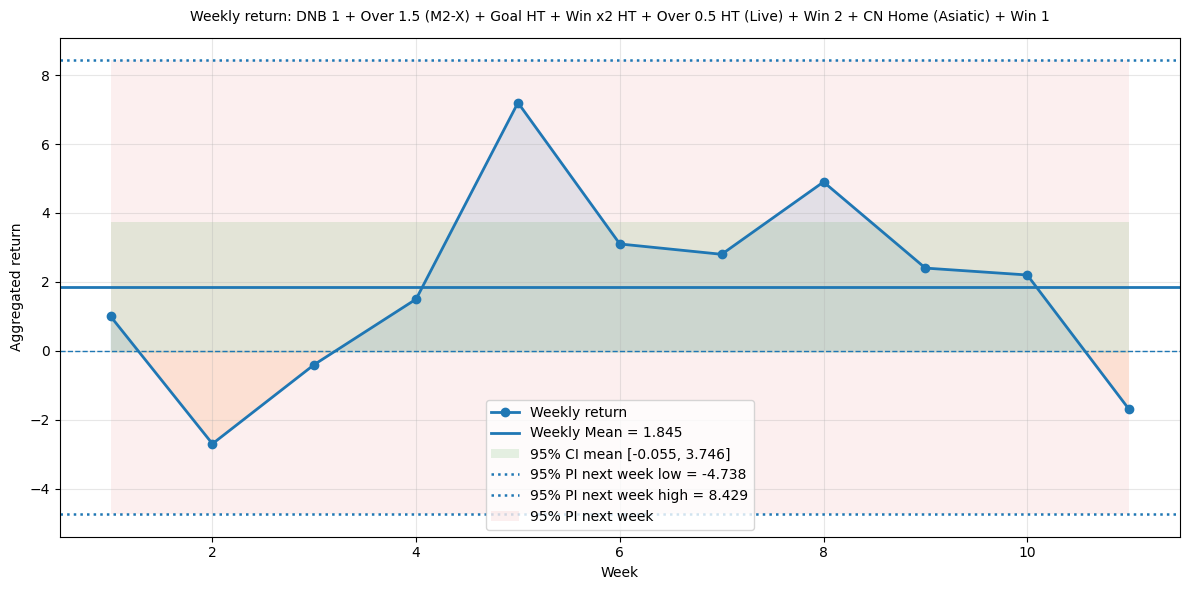

In [131]:
weekly_return, stats = analyze_strategies(df, strategies=['DNB 1', 'Over 1.5 (M2-X)', 'Goal HT', 'Win x2 HT', 'Over 0.5 HT (Live)', 'Win 2', 'CN Home (Asiatic)', 'Win 1'], print_pi=True)

### Note:
- ritorno medio minore ma CI low > 0 -> al 95% il ritorno medio settimanale è positivo
- PI molto meno variabile

## Approccio 3: scommetto solo sui campionati migliori

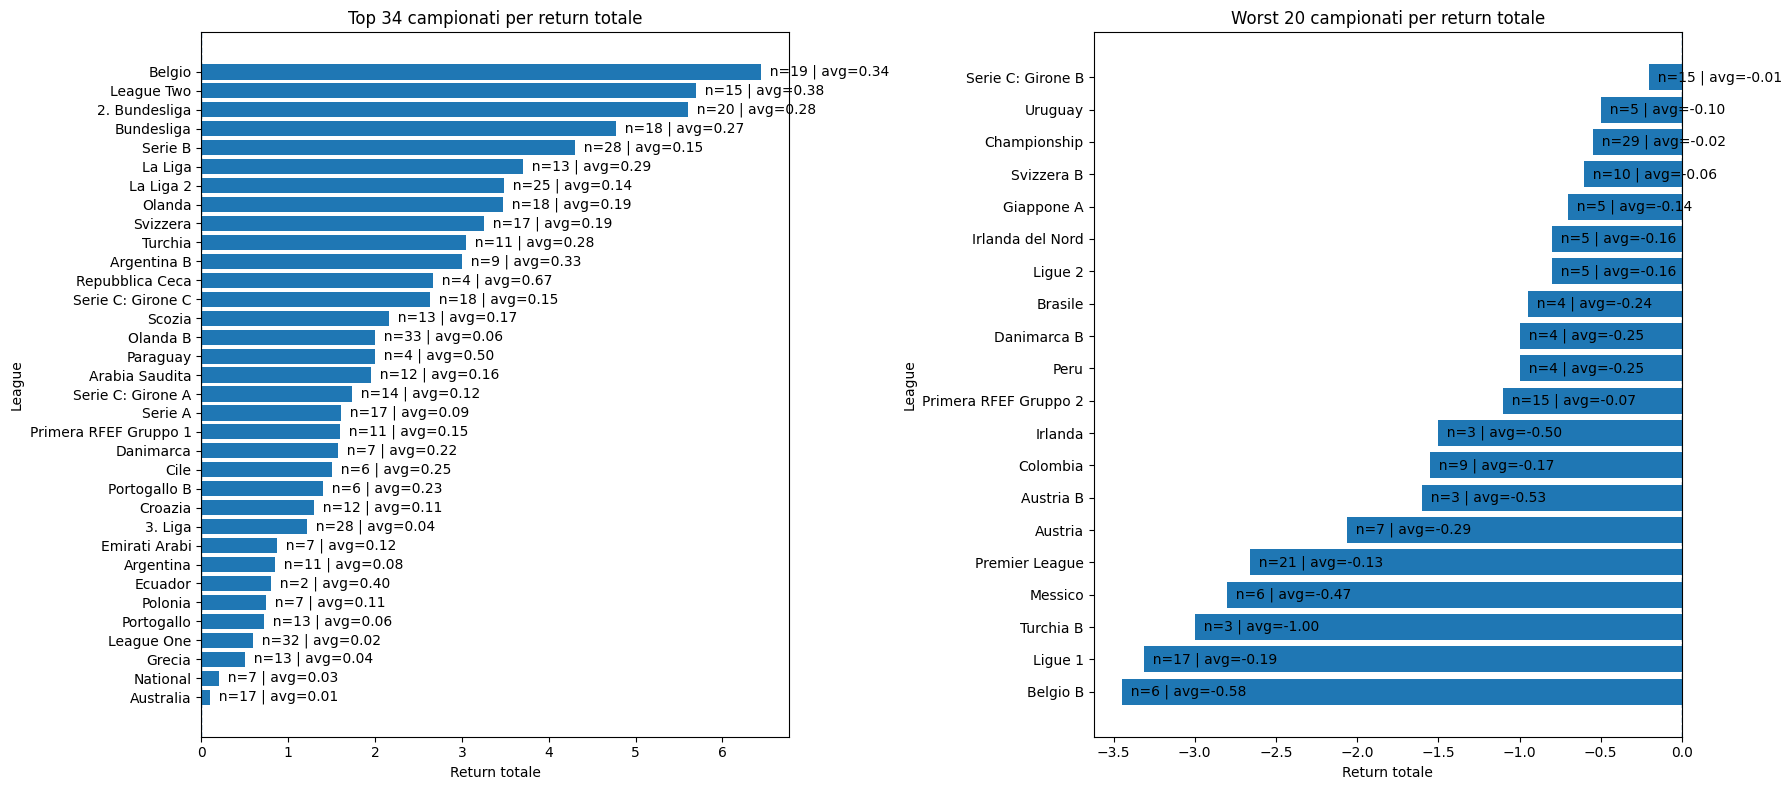

In [132]:
best_leagues = get_best_leagues(df)

In [133]:
threshold = best_leagues["n_matches"].quantile(q=0.1)
print(f"Threshold: {threshold}")
league_list = list(best_leagues[best_leagues["n_matches"] > threshold].index)

Threshold: 6.0


In [134]:
# Vedo quali sono le migliori scommesse per i campionati con ritorno positivo (considero solo campionati grafico a sx)
get_best_strategies(df, leagues=league_list)

,weekly_mean_return,weekly_std_return,weekly_counts,total_counts,accuracy
BTTS,2.53,7.58,4.55,50,0.76
Win x2 HT,0.83,1.28,1.36,15,0.85
Over 1.5 (M2-X),0.81,1.25,5.00,55,0.80
Goal HT,0.68,1.42,3.82,42,0.85
Over 0.5 HT (Live),0.67,0.87,4.00,44,0.86
DNB 1,0.65,2.18,5.73,63,0.78
Win 1,0.33,0.66,1.36,15,0.83
DNB 2,-0.03,1.12,2.82,31,0.70
Multigoal 1-2 Home,-0.09,1.08,0.45,5,0.50
CN Home (Asiatic),-0.11,1.44,2.36,26,0.59


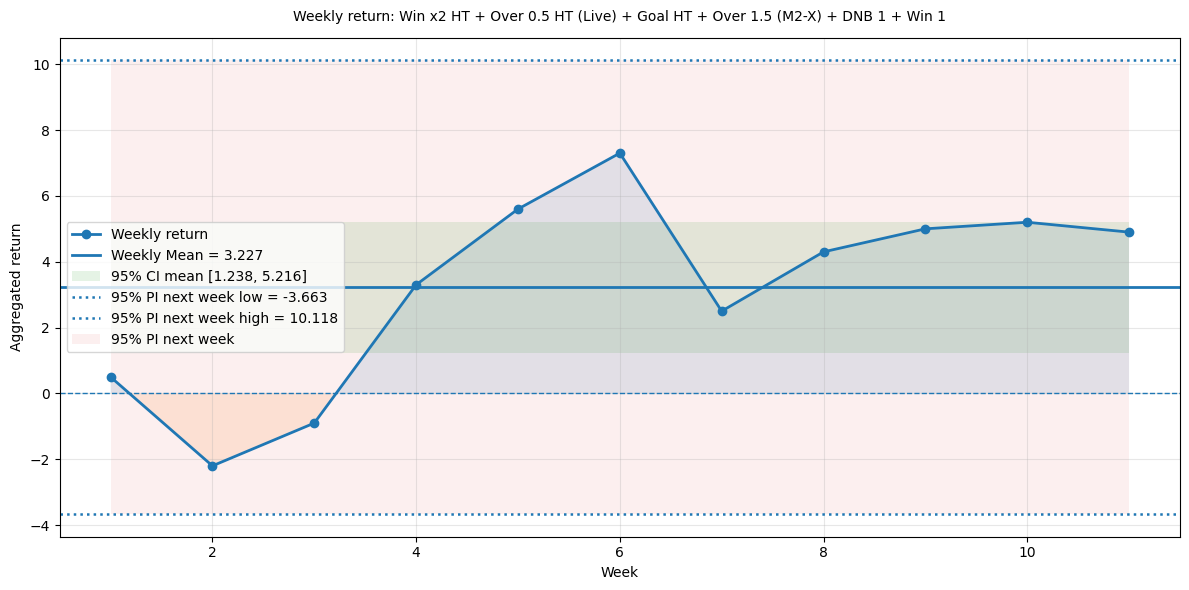

In [135]:
# Prendo le strategie migliori togliendo CN Home perchè ha ritorno negativo e BTTS per alta volatilità
best_strategies = ['Win x2 HT', 'Over 0.5 HT (Live)', 'Goal HT', 'Over 1.5 (M2-X)', 'DNB 1', 'Win 1']

weekly_return, stats_1 = analyze_strategies(df, strategies=best_strategies, leagues=league_list, print_pi=True)

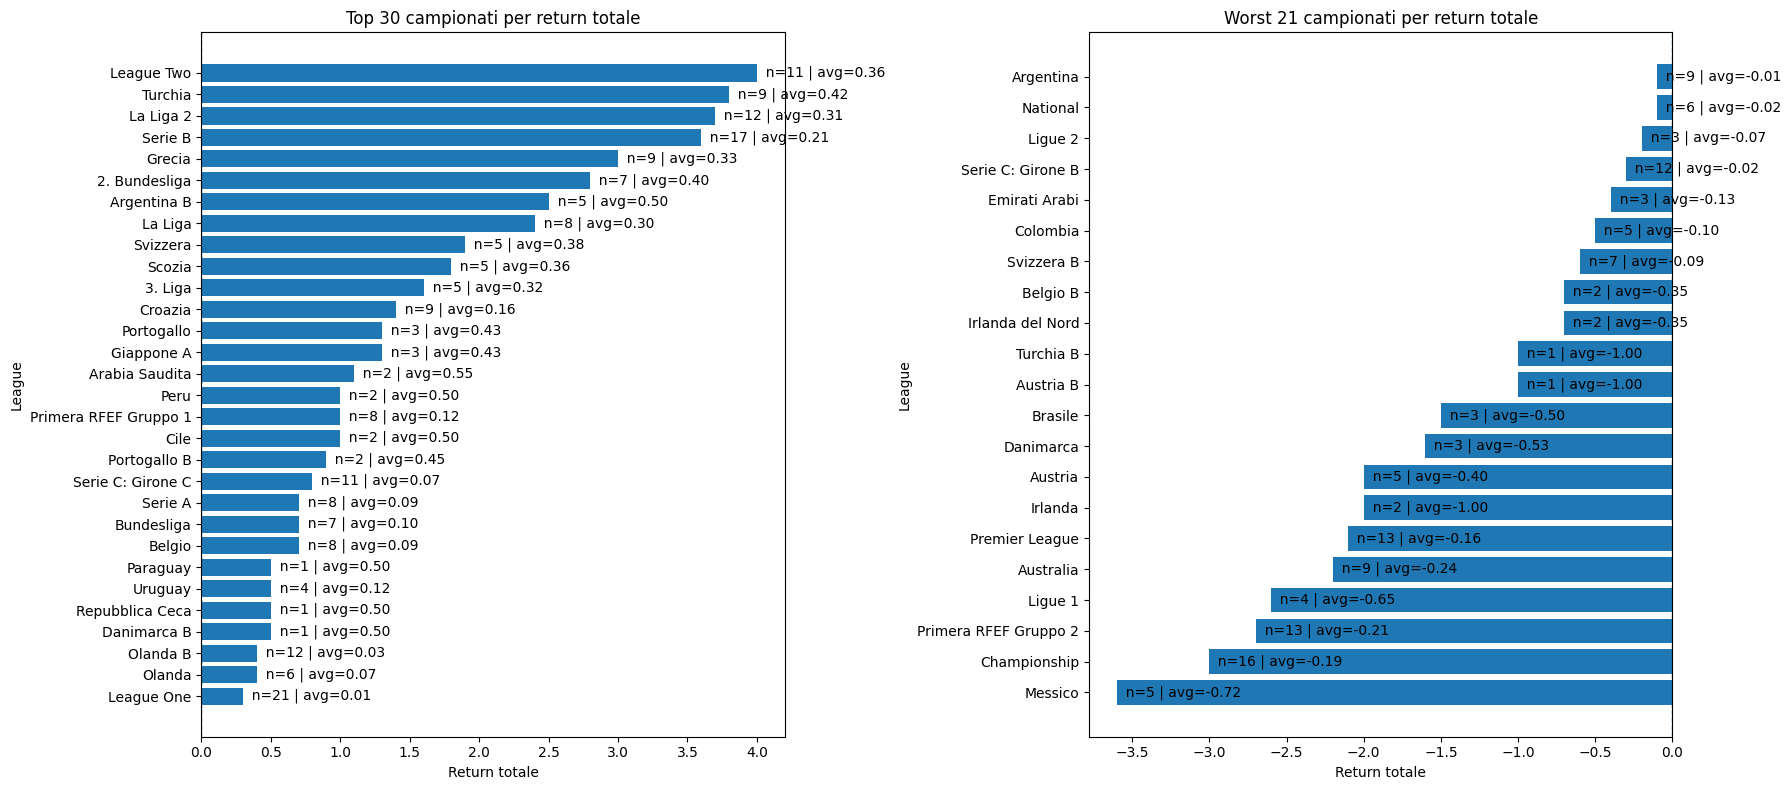

Threshold: 1.9000000000000004


In [136]:
# Find the best leageus for the best strategies 
best_leagues = get_best_leagues(df, strategies=best_strategies)
threshold = best_leagues["n_matches"].quantile(q=0.1)
league_list = list(best_leagues[best_leagues["n_matches"] > threshold].index)

print(f"Threshold: {threshold}")

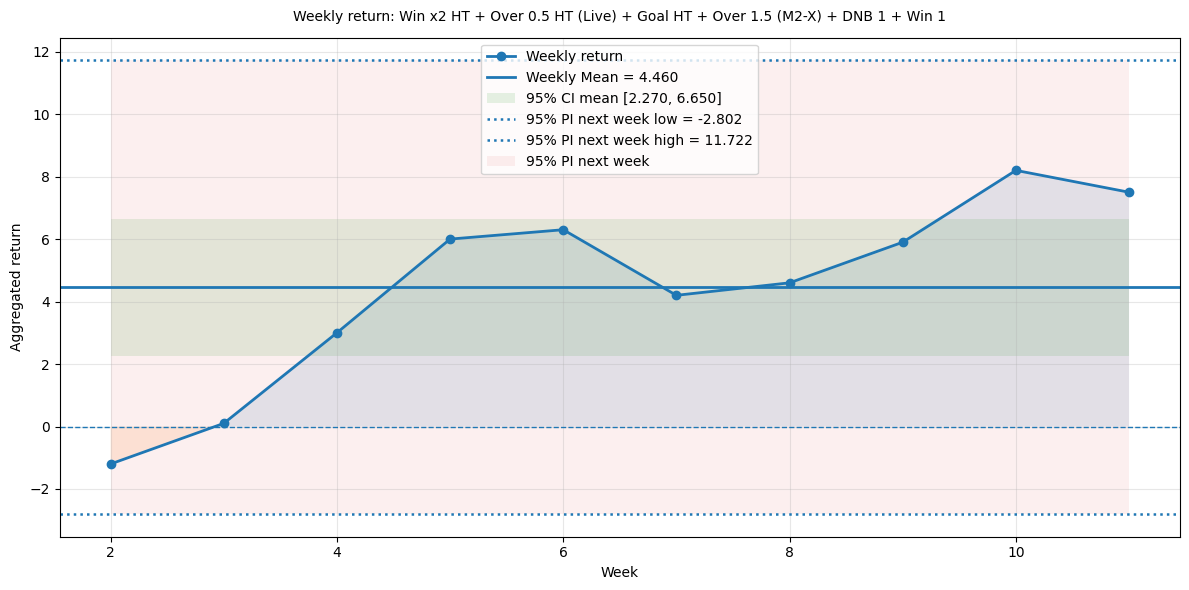

In [137]:
weekly_return, stats_2 = analyze_strategies(df, strategies=best_strategies, leagues=league_list, print_pi=True)

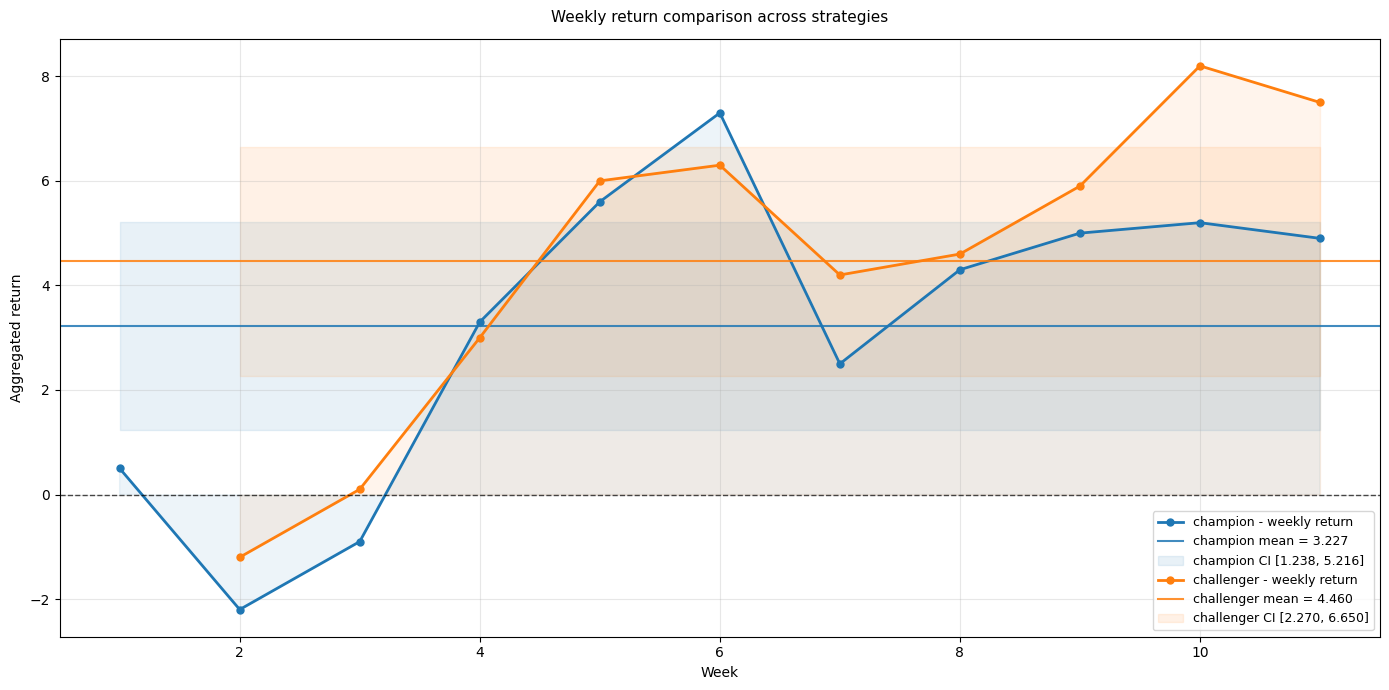

In [ ]:
strategies_to_compare = {"champion": stats_1, "challenger": stats_2}

aggregated_data, summary_df = compare_strategies(
    df=df,
    strategies=strategies_to_compare,
    show_ci=True,
    show_pi=False
)

In [142]:
summary_df

,label,strategy,leagues,n_weeks,expected_bets_per_week,mean_weekly_agg_return,std_weekly_agg_return,sem,ci_low,ci_high,pi_low,pi_high
0,champion,"[Win x2 HT, Over 0.5 HT (Live), Goal HT, Over ...","[Belgio, League Two, 2. Bundesliga, Bundesliga...",11,21,3.23,2.96,0.89,1.24,5.22,-3.66,10.12
1,challenger,"[Win x2 HT, Over 0.5 HT (Live), Goal HT, Over ...","[League Two, Turchia, La Liga 2, Serie B, Grec...",10,19,4.46,3.06,0.97,2.27,6.65,-2.80,11.72


### Note:
- Ritorno medio più alto del precedente ma ancora minore del primo
- Confidenza molto più alta sia del primo che del secondo (CI low 1.5 vuol dire che il valor medio sul lungo periodo è almeno 1.53 al 95% di confidenza)
- Variabilità sulla settimana (PI) maggiore di prima ma più spostato verso l'alto